# Comparison of reskilling simulation runs
Felix Zaussinger | 21.11.2022

**Core Analysis Goal(s)**
1. Gather the data of all baseline simulations (1), with/ (2) without regional constraints to (a) optimally targeted reskilling and (b) random reskilling scenario.
2. Run this comparison for the three different viability thresholds (low, mid, high).
3. Compare the distributions and run tests on significant differences.

**Key Insight(s)**
1.
2.
3.

In [64]:
import copy
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

from tqdm import tqdm
import pickle
from scipy import stats

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Read data

##### Define model setting combinations

In [65]:
job_pools = ["brown_techchange"]  # ["coal", "brown_techchange", "brown"]

# template: "reskilling_final_thresh-{threshold}"
thresholds = ["viable-isco4d"]  # ["viable-low", "low", "perc", "emp"]

regional_constraints = ["regC", "no-regC"]

reskilling_modes = [
    #"baseline",
    "reskill-random",
    "reskill-coreWeight",
    #"reskill-digital",
    # "coreness_percentile",
    "reskill-optimal",
]

##### Collect raw model output across all options (reg/no-reg) and scenarios

In [66]:
# names
folder_name = "reskilling_final_thresh-{threshold}"
fmt_string = "{reskilling_mode}_wage-opt_{regional_constraint}_2019"

# iterate across all options
data_store = {}
for threshold in thresholds:
    for reskilling_mode in reskilling_modes:
        for regional_constraint in regional_constraints:
            fpath = os.path.join(
                useful_paths.figure_dir,
                #"test",  # todo: delete after testing
                folder_name.format(threshold=threshold),
                fmt_string.format(
                    reskilling_mode=reskilling_mode,
                    regional_constraint=regional_constraint,
                ),
                "{}.pkl".format(
                    fmt_string.format(
                        reskilling_mode=reskilling_mode,
                        regional_constraint=regional_constraint,
                    )
                ),
            )
            data_store[
                (threshold, reskilling_mode, regional_constraint)
            ] = pd.read_pickle(fpath)

# save to pickle
fdir_out = os.path.join(
    useful_paths.figure_dir,
    #"test",
    folder_name.format(threshold=threshold),
    "model_data_store.pkl"
)

with open(fdir_out, "wb") as handle:
    pickle.dump(data_store, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [67]:
data_store[("viable-isco4d", "reskill-optimal", "no-regC")]["brown_techchange"]["DE"]

AGE        COEFF  COEFF_share_brown_sl  \
COUNTRYW NUTS_ID NACE1D                                            
DE       DE11    A      49.50    15,829.66              4,516.42   
                 B      53.50    39,257.79             16,741.44   
                 C      41.92 6,971,397.01          1,399,802.83   
                 D      44.59   213,975.96             19,338.78   
                 E      43.20    91,389.98             15,091.31   
...                       ...          ...                   ...   
         DEG0    O      50.60   219,428.49             19,805.22   
                 P      39.33    53,298.19              5,606.51   
                 Q      46.32    76,062.03              6,673.88   
                 R      49.50    19,942.34              1,893.19   
                 S      53.25    44,306.40              3,234.57   

                         COEFF_share_brown_slt  COEFF_share_green  \
COUNTRYW NUTS_ID NACE1D                                             
DE       DE11    A                      924.00               0.00   
                 B                    9,328.00             488.28   
                 C                  502,568.00         237,793.89   
                 D                   16,324.00          17,675.29   
                 E                   10,032.00           7,709.07   
...                                        ...                ...   
         DEG0    O                   18,480.00           6,959.68   
                 P                    3,960.00           2,278.81   
                 Q                    4,136.00             143.26   
                 R                    1,430.00             512.44   
                 S                    3,212.00             745.66   

                         COEFF_share_neutral_sl  COEFF_share_neutral_slt  \
COUNTRYW NUTS_ID NACE1D                                                    
DE       DE11    A                    11,313.24                14,952.69   
                 B                    22,028.07                29,533.87   
                 C                 5,333,800.29             6,252,800.00   
                 D                   176,961.89               180,684.90   
                 E                    68,589.59                73,913.40   
...                                         ...                      ...   
         DEG0    O                   192,663.60               194,750.20   
                 P                    45,412.86                47,213.94   
                 Q                    69,244.89                71,981.02   
                 R                    17,536.72                18,082.95   
                 S                    40,326.17                40,511.95   

                             NOBS  transition_viable_step_0  \
COUNTRYW NUTS_ID NACE1D                                       
DE       DE11    A          88.00                      0.25   
                 B         220.00                      0.10   
                 C      43,098.00                      0.46   
                 D       1,276.00                      0.29   
                 E         550.00                      0.20   
...                           ...                       ...   
         DEG0    O       1,496.00                      0.32   
                 P         330.00                      0.47   
                 Q         484.00                      0.41   
                 R         132.00                      0.00   
                 S         264.00                      0.17   

                         n_viable_transitions_step_0  \
COUNTRYW NUTS_ID NACE1D                                
DE       DE11    A                              0.75   
                 B                              0.10   
                 C                              0.92   
                 D                              0.88   
                 E                              0.28   
...                                       

## Preprocessing

Build up aggregated data cube of modelling results across all scenarios

In [68]:
# aggdict = {
#     "n_viable_transitions": np.mean,
#     "earnings_delta_closest_switch_sum_mio": np.sum,
#     "reskilling_mode": "first",
#     "viability_threshold": "first",
#     "regional_constraint": "first",
#     "job_pool": "first",
# }
#
# keep_vars = [
#     "n_viable_transitions",
#     "earnings_delta_closest_switch_sum_mio",
#     "NUTS_ID",
#     "NACE1D",
#     "COUNTRYW",
# ]

In [69]:
# data_transformed_regions = []
# data_transformed_sectors = []
# for model_version in tqdm(list(data_store.keys())):
#     # threshold - reskilling - regional constraint
#     sub_dict = data_store[model_version]
#
#     for job_pool in job_pools:
#         # pool - country - DATA
#         df_pool = pd.concat(list(sub_dict[job_pool].values()))
#
#         # only keep select variables
#         df_pool_sel = df_pool.loc[:, keep_vars]
#
#         # add metadata of model run
#         df_pool_sel["job_pool"] = job_pool
#         df_pool_sel["viability_threshold"] = model_version[0]
#         df_pool_sel["reskilling_mode"] = model_version[1]
#         df_pool_sel["regional_constraint"] = model_version[2]
#
#         # aggregate to regional level
#         aggby = ["COUNTRYW", "NUTS_ID"]
#         df_pool_sel_reg = df_pool_sel.groupby(aggby).agg(aggdict)
#         data_transformed_regions.append(df_pool_sel_reg)
#
#         # aggregate to sectoral level
#         aggby = ["COUNTRYW", "NACE1D"]
#         df_pool_sel_sec = df_pool_sel.groupby(aggby).agg(aggdict)
#         data_transformed_sectors.append(df_pool_sel_sec)

In [70]:
data_tidy = []
for model_version in tqdm(list(data_store.keys())):
    # threshold - reskilling - regional constraint
    sub_dict = data_store[model_version]

    for job_pool in job_pools:
        # pool - country - DATA
        df_pool = pd.concat(list(sub_dict[job_pool].values()))

        # only keep select variables
        df_pool_sel = df_pool

        # add metadata of model run
        df_pool_sel["job_pool"] = job_pool
        df_pool_sel["viability_threshold"] = model_version[0]
        df_pool_sel["reskilling_mode"] = model_version[1]
        df_pool_sel["regional_constraint"] = model_version[2]

        # append
        data_tidy.append(df_pool_sel)

df_tidy = pd.concat(data_tidy)
df_tidy = df_tidy.reset_index()

  0%|          | 0/6 [00:00<?, ?it/s]C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_15592\2977751110.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pool_sel["job_pool"] = job_pool
C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_15592\2977751110.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pool_sel["viability_threshold"] = model_version[0]
C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_15592\2977751110.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

Clean data set

In [71]:
df_tidy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21846 entries, 0 to 21845
Columns: 125 entries, COUNTRYW to regional_constraint
dtypes: float64(118), object(7)
memory usage: 20.8+ MB


In [72]:
# rename job pools
df_tidy = df_tidy.replace(
    {"job_pool": {"coal": "CPO", "brown_techchange": "FFPOTC", "brown": "FFPO"}}
)

# make sure entries for countries with missing earnings data_transitions are coded as NaNs
earnings_data_missing = ["AT", "ES", "CZ", "NO", "SE", "GR", "IS", "UK"]
df_tidy.loc[
    df_tidy["COUNTRYW"].isin(earnings_data_missing),
    "earnings_delta_closest_switch_sum_mio",
] = np.nan

In [73]:
from src.modelling.reskilling import ReskillingPathways
rp = ReskillingPathways()

In [74]:
df_tidy = pd.merge(df_tidy, rp.nace_labels, on="NACE1D", how="left")

In [75]:
df_tidy.columns

Index(['COUNTRYW', 'NUTS_ID', 'NACE1D', 'AGE', 'COEFF', 'COEFF_share_brown_sl',
       'COEFF_share_brown_slt', 'COEFF_share_green', 'COEFF_share_neutral_sl',
       'COEFF_share_neutral_slt',
       ...
       'transition_viable_step_21',
       'earnings_delta_closest_switch_sum_mio_step_21', 'job_pool',
       'viability_threshold', 'reskilling_mode', 'regional_constraint',
       'earnings_delta_closest_switch_sum_mio', 'NACE1D_label',
       'NACE1D_label_short', 'paper_selection'],
      dtype='object', length=129)

##### Save concatenated results data

In [76]:
df_tidy

,COUNTRYW,NUTS_ID,NACE1D,AGE,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,NOBS,earnings_delta_closest_switch_step_0,earnings_delta_closest_switch_sum_step_0,n_viable_transitions_step_0,transition_viable_step_0,earnings_delta_closest_switch_sum_mio_step_0,earnings_delta_closest_switch_step_1,earnings_delta_closest_switch_sum_step_1,n_viable_transitions_step_1,transition_viable_step_1,earnings_delta_closest_switch_sum_mio_step_1,earnings_delta_closest_switch_step_2,earnings_delta_closest_switch_sum_step_2,n_viable_transitions_step_2,transition_viable_step_2,earnings_delta_closest_switch_sum_mio_step_2,earnings_delta_closest_switch_step_3,earnings_delta_closest_switch_sum_step_3,n_viable_transitions_step_3,transition_viable_step_3,earnings_delta_closest_switch_sum_mio_step_3,earnings_delta_closest_switch_step_4,earnings_delta_closest_switch_sum_step_4,n_viable_transitions_step_4,transition_viable_step_4,earnings_delta_closest_switch_sum_mio_step_4,earnings_delta_closest_switch_step_5,earnings_delta_closest_switch_sum_step_5,n_viable_transitions_step_5,transition_viable_step_5,earnings_delta_closest_switch_sum_mio_step_5,earnings_delta_closest_switch_step_6,earnings_delta_closest_switch_sum_step_6,n_viable_transitions_step_6,transition_viable_step_6,earnings_delta_closest_switch_sum_mio_step_6,earnings_delta_closest_switch_step_7,earnings_delta_closest_switch_sum_step_7,n_viable_transitions_step_7,transition_viable_step_7,earnings_delta_closest_switch_sum_mio_step_7,earnings_delta_closest_switch_step_8,earnings_delta_closest_switch_sum_step_8,n_viable_transitions_step_8,transition_viable_step_8,earnings_delta_closest_switch_sum_mio_step_8,earnings_delta_closest_switch_step_9,earnings_delta_closest_switch_sum_step_9,n_viable_transitions_step_9,transition_viable_step_9,...,transition_viable_step_11,earnings_delta_closest_switch_sum_mio_step_11,earnings_delta_closest_switch_step_12,earnings_delta_closest_switch_sum_step_12,n_viable_transitions_step_12,transition_viable_step_12,earnings_delta_closest_switch_sum_mio_step_12,earnings_delta_closest_switch_step_13,earnings_delta_closest_switch_sum_step_13,n_viable_transitions_step_13,transition_viable_step_13,earnings_delta_closest_switch_sum_mio_step_13,earnings_delta_closest_switch_step_14,earnings_delta_closest_switch_sum_step_14,n_viable_transitions_step_14,transition_viable_step_14,earnings_delta_closest_switch_sum_mio_step_14,earnings_delta_closest_switch_step_15,earnings_delta_closest_switch_sum_step_15,n_viable_transitions_step_15,transition_viable_step_15,earnings_delta_closest_switch_sum_mio_step_15,earnings_delta_closest_switch_step_16,earnings_delta_closest_switch_sum_step_16,n_viable_transitions_step_16,transition_viable_step_16,earnings_delta_closest_switch_sum_mio_step_16,earnings_delta_closest_switch_step_17,earnings_delta_closest_switch_sum_step_17,n_viable_transitions_step_17,transition_viable_step_17,earnings_delta_closest_switch_sum_mio_step_17,earnings_delta_closest_switch_step_18,earnings_delta_closest_switch_sum_step_18,n_viable_transitions_step_18,transition_viable_step_18,earnings_delta_closest_switch_sum_mio_step_18,earnings_delta_closest_switch_step_19,earnings_delta_closest_switch_sum_step_19,n_viable_transitions_step_19,transition_viable_step_19,earnings_delta_closest_switch_sum_mio_step_19,earnings_delta_closest_switch_step_20,earnings_delta_closest_switch_sum_step_20,n_viable_transitions_step_20,transition_viable_step_20,earnings_delta_closest_switch_sum_mio_step_20,earnings_delta_closest_switch_step_21,earnings_delta_closest_switch_sum_step_21,n_viable_transitions_step_21,transition_viable_step_21,earnings_delta_closest_switch_sum_mio_step_21,job_pool,viability_threshold,reskilling_mode,regional_constraint,earnings_delta_closest_switch_sum_mio,NACE1D_label,NACE1D_label_short,paper_selection
0,AT,AT11,A,32.00,"3,757.22","1,239.50",330.00,0.00,"2,517.72","3,562.44",176.00,0.00,0.00,0.08,0.03

##### Reduce data set to core sectors

In [77]:
df_tidy = df_tidy.loc[df_tidy["paper_selection"]]

## Visualisation

Statannotations settings

In [78]:
from statannotations.Annotator import Annotator

pairs = [
    # with regional constraints
    (("regC", "baseline"), ("regC", "reskill-optimal")),
    (("regC", "baseline"), ("regC", "reskill-random")),
    (("regC", "baseline"), ("regC", "reskill-coreWeight")),
    (("regC", "baseline"), ("regC", "reskill-digital")),
    # w/o regional constraints
    (("no-regC", "baseline"), ("no-regC", "reskill-optimal")),
    (("no-regC", "baseline"), ("no-regC", "reskill-random")),
    (("no-regC", "baseline"), ("no-regC", "reskill-coreWeight")),
    (("no-regC", "baseline"), ("no-regC", "reskill-digital")),
]

# annotate stats
pairs_regional_hue = [
    # with regional constraints
    (("baseline", "regC"), ("baseline", "no-regC")),
    (("reskill-random", "regC"), ("reskill-random", "no-regC")),
    (("reskill-coreWeight", "regC"), ("reskill-coreWeight", "no-regC")),
    (("reskill-digital", "regC"), ("reskill-digital", "no-regC")),
    (("reskill-optimal", "regC"), ("reskill-optimal", "no-regC")),
    # w/o regional constraints
]

##### Plotting parameters

In [79]:
alpha = 0.001
test = "Kruskal"
comparisons_correction = "Benjamini-Hochberg"
text_format = "star"
loc = "inside"
show_test_name = False
verbose = False
palette = "BrBG"

##### Errorbar custom function

In [80]:
def iqr_errorbar(arr):
    iqr = stats.iqr(arr)
    median = np.median(arr)
    return median - iqr, median + iqr

#### Reskilling journeys

Note: Use relplot() to combine lineplot() and FacetGrid. This allows grouping within additional categorical variables. Using relplot() is safer than using FacetGrid directly, as it ensures synchronization of the semantic mappings across facets:

In [81]:
# define columns to be melted
transitions_cols = df_tidy.columns[df_tidy.columns.str.startswith("n_viable_transitions")].values
viability_cols = df_tidy.columns[df_tidy.columns.str.startswith("n_viable_transitions")].values
earnings_cols = df_tidy.columns[df_tidy.columns.str.startswith("earnings_delta_closest_switch_step")].values

index_cols = set(df_tidy.columns) - set(transitions_cols) - set(earnings_cols)

In [82]:
# melt to long format
df_tidy_long_transitions = df_tidy.melt(id_vars=index_cols, value_vars=transitions_cols, var_name="reskilling_step", value_name="n_transitions")
df_tidy_long_transitions["reskilling_step"] = df_tidy_long_transitions["reskilling_step"].str.split("_").str[-1].astype(int)

df_tidy_long_earnings = df_tidy.melt(id_vars=index_cols, value_vars=earnings_cols, var_name="reskilling_step", value_name="earnings_delta")
df_tidy_long_earnings["reskilling_step"] = df_tidy_long_earnings["reskilling_step"].str.split("_").str[-1].astype(int)
df_tidy_long_earnings["earnings_delta_mio"] = df_tidy_long_earnings["earnings_delta"] / 10**6

##### Save wide and long data

In [83]:
# todo
df_tidy_long_transitions


,earnings_delta_closest_switch_sum_step_5,earnings_delta_closest_switch_sum_mio_step_16,earnings_delta_closest_switch_sum_mio_step_2,earnings_delta_closest_switch_sum_step_9,earnings_delta_closest_switch_sum_step_17,transition_viable_step_13,earnings_delta_closest_switch_sum_mio_step_18,earnings_delta_closest_switch_sum_step_12,transition_viable_step_5,transition_viable_step_10,COUNTRYW,transition_viable_step_14,transition_viable_step_6,transition_viable_step_7,earnings_delta_closest_switch_sum_mio_step_15,earnings_delta_closest_switch_sum_step_3,earnings_delta_closest_switch_sum_mio,NACE1D,COEFF_share_brown_sl,earnings_delta_closest_switch_sum_mio_step_8,COEFF_share_neutral_sl,earnings_delta_closest_switch_sum_mio_step_3,transition_viable_step_4,earnings_delta_closest_switch_sum_mio_step_12,earnings_delta_closest_switch_sum_mio_step_4,paper_selection,earnings_delta_closest_switch_sum_step_6,earnings_delta_closest_switch_sum_mio_step_1,transition_viable_step_8,COEFF_share_brown_slt,reskilling_mode,earnings_delta_closest_switch_sum_mio_step_6,transition_viable_step_11,NOBS,COEFF_share_green,transition_viable_step_20,transition_viable_step_2,earnings_delta_closest_switch_sum_step_18,earnings_delta_closest_switch_sum_mio_step_13,earnings_delta_closest_switch_sum_step_7,transition_viable_step_16,earnings_delta_closest_switch_sum_step_14,earnings_delta_closest_switch_sum_step_10,earnings_delta_closest_switch_sum_step_1,earnings_delta_closest_switch_sum_mio_step_7,earnings_delta_closest_switch_sum_mio_step_20,transition_viable_step_0,earnings_delta_closest_switch_sum_mio_step_11,regional_constraint,earnings_delta_closest_switch_sum_mio_step_0,earnings_delta_closest_switch_sum_step_13,job_pool,transition_viable_step_19,AGE,transition_viable_step_17,transition_viable_step_18,viability_threshold,transition_viable_step_12,earnings_delta_closest_switch_sum_step_0,earnings_delta_closest_switch_sum_mio_step_19,earnings_delta_closest_switch_sum_step_8,transition_viable_step_9,earnings_delta_closest_switch_sum_mio_step_10,earnings_delta_closest_switch_sum_step_11,NACE1D_label_short,COEFF,earnings_delta_closest_switch_sum_mio_step_5,NUTS_ID,COEFF_share_neutral_slt,earnings_delta_closest_switch_sum_mio_step_21,earnings_delta_closest_switch_sum_step_15,earnings_delta_closest_switch_sum_step_21,earnings_delta_closest_switch_sum_step_20,earnings_delta_closest_switch_sum_step_2,earnings_delta_closest_switch_sum_step_16,NACE1D_label,earnings_delta_closest_switch_sum_step_4,transition_viable_step_21,earnings_delta_closest_switch_sum_mio_step_17,transition_viable_step_15,earnings_delta_closest_switch_sum_step_19,earnings_delta_closest_switch_sum_mio_step_9,transition_viable_step_3,transition_viable_step_1,earnings_delta_closest_switch_sum_mio_step_14,reskilling_step,n_transitions
0,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.03,0.05,AT,0.07,0.04,0.04,0.00,0.00,NaN,A,"1,239.50",0.00,"2,517.72",0.00,0.03,0.00,0.00,True,0.00,0.00,0.04,330.00,reskill-random,0.00,0.05,176.00,0.00,0.00,0.03,0.00,0.00,0.00,0.09,0.00,0.00,0.00,0.00,0.00,0.03,0.00,regC,0.00,0.00,FFPOTC,0.00,32.00,0.00,0.00,viable-isco4d,0.06,0.00,0.00,0.00,0.04,0.00,0.00,"Agri., Forest., Fish.","3,757.22",0.00,AT11,"3,562.44",0.00,0.00,0.00,0.00,0.00,0.00,"Agriculture, Forestry and Fishing",0.00,0.00,0.00,0.08,0.00,0.00,0.03,0.03,0.00,0,0.08
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00,AT,0.00,0.03,0.00,0.00,0.00,NaN,B,94.15,0.00,"1,337.67",0.00,0.03,0.00,0.00,True,0.00,0.00,0.00,110.00,reskill-random,0.00,0.00,66.00,63.19,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,regC,0.00,0.00,FFPOTC,0.00,33.67,0.00,0.00,viable-isco4d,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Mining,"1,495.01",0.00,AT11,"1,337.67",0.00,0.00,0.00,0.00,0.00,0.00,Mining and Quarrying,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.02,0.00,0,0.02
2,0.00,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.02,0.02,AT,0.03,0.02,0.02,0.00,0.00,NaN,C,"23,010.18",0.00,"76,925.83",0.00,0.02,0.00,0.00,True,0.00,0.00,0.02,"7,678.00",reskill-

##### Fig 5a (TEST): Transition numbers across reskilling journey, Boxplot

In [84]:
results_dir = os.path.join(
    useful_paths.figure_dir,
    folder_name.format(threshold=threshold)
)

##### Plotting parameters

In [98]:
from statannotations.Annotator import Annotator

pairs = []
reskilling_steps = np.arange(0, df_tidy_long_transitions["reskilling_step"].max())
for step in reskilling_steps:
    pair = ((step, "reskill-random"), (step, "reskill-optimal"))
    pairs.append(pair)

alpha = 0.001
test = "Kruskal"
comparisons_correction = "Benjamini-Hochberg"
text_format = "star"
loc = "outside"
show_test_name = False
verbose = False

# shared across plot versions
job_pool = "FFPOTC"
hue_order = ["reskill-optimal", "reskill-random"]
order = reskilling_steps
palette = "BrBG_r"
figsize=(6, 4)

# errorbar
seed = 42
errorbar = ("ci", 95)
errorbar = ("sd")
estimator = np.mean

# subset data_transitions
data_transitions = df_tidy_long_transitions.loc[
    (df_tidy_long_transitions["job_pool"] == job_pool) & (df_tidy_long_transitions["reskilling_mode"].isin(hue_order))
]

data_earnings = df_tidy_long_earnings.loc[
    (df_tidy_long_earnings["job_pool"] == job_pool) & (df_tidy_long_earnings["reskilling_mode"].isin(hue_order))
]

##### Fig 5a: Transition numbers across reskilling journey, Main

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


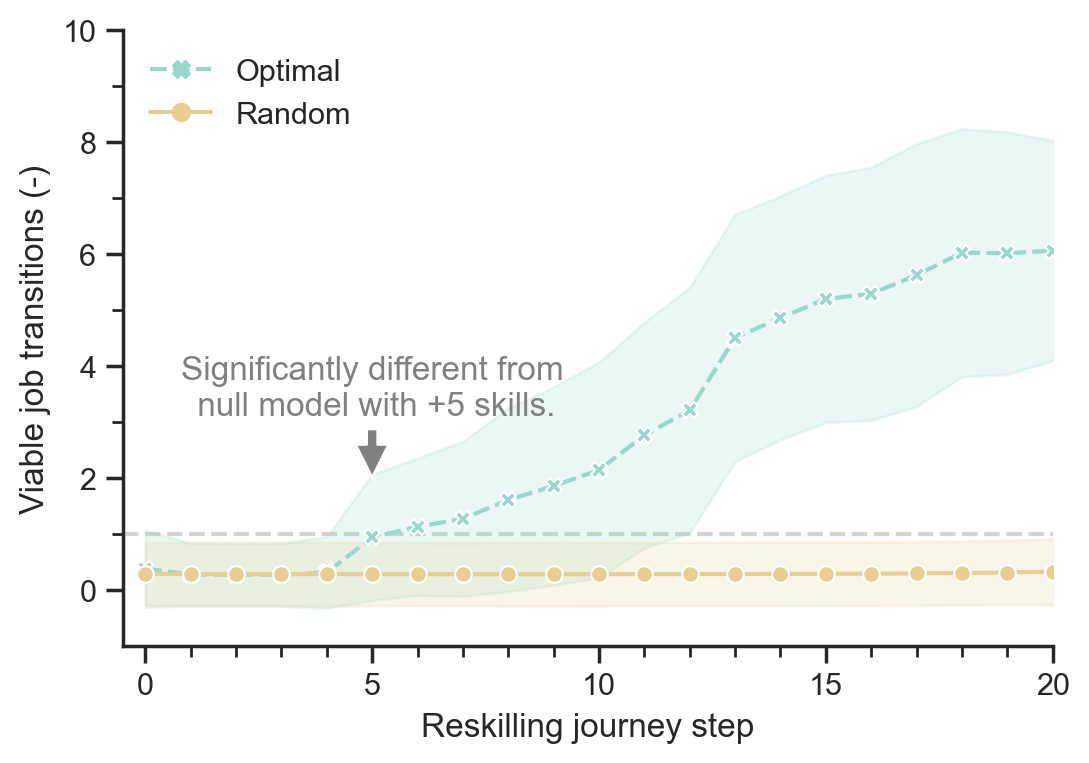

In [99]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "reskilling_mode"  # "NACE1D"
size = None

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_transitions,
    x=x,
    y=y,
    hue=hue,
    hue_order=hue_order,
    style=style,
    size=size,
    dashes=True,
    markers=True,
    estimator=estimator,
    errorbar=errorbar,
    palette=palette,
    seed=seed,
    ax=ax,
    legend="brief",
)

# axes limits and ticks
xmax = 20
ymax = 10

ax.set_xlim(-0.5, xmax)
ax.set_ylim(-1, ymax)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

# annotation
x_sign, y_sign = 5, 2
text = "Significantly different from\n null model with +{} skills.".format(x_sign)

ax.annotate(
    text, xy=(x_sign, y_sign),
    xytext=(x_sign, y_sign+1),
    arrowprops=dict(facecolor='grey', shrink=0.01), color="grey",
    horizontalalignment='center', verticalalignment='bottom',
)

# beautify legend
handles, labels = ax.get_legend_handles_labels()
legend_locs = [0, 1, 2]
handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
labels_new = ['Optimal', 'Random', None, None, None, None]
ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False, loc="upper left")

# test statistic
annotator = Annotator(
    ax=ax, pairs=pairs, data=data_transitions, x=x, y=y, order=order, hue=hue
)
annotator.configure(
    alpha=alpha,
    test=test,
    comparisons_correction=comparisons_correction,
    text_format="star",
    loc=loc,
    show_test_name=show_test_name,
    verbose=True,
)
# annotator.apply_and_annotate()

# styling
ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
ax.set_ylabel("Viable job transitions (-)")
ax.set_xlabel("Reskilling journey step")
#plotting_utils.move_legend_to_right(ax)
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5a: Transition numbers across reskilling journey, Regional Constraints

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_15592\2203973281.py:56: UserWarning: Legend does not support None instances.
A proxy artist may be used instead.
See: https://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
  ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False, loc="upper left")


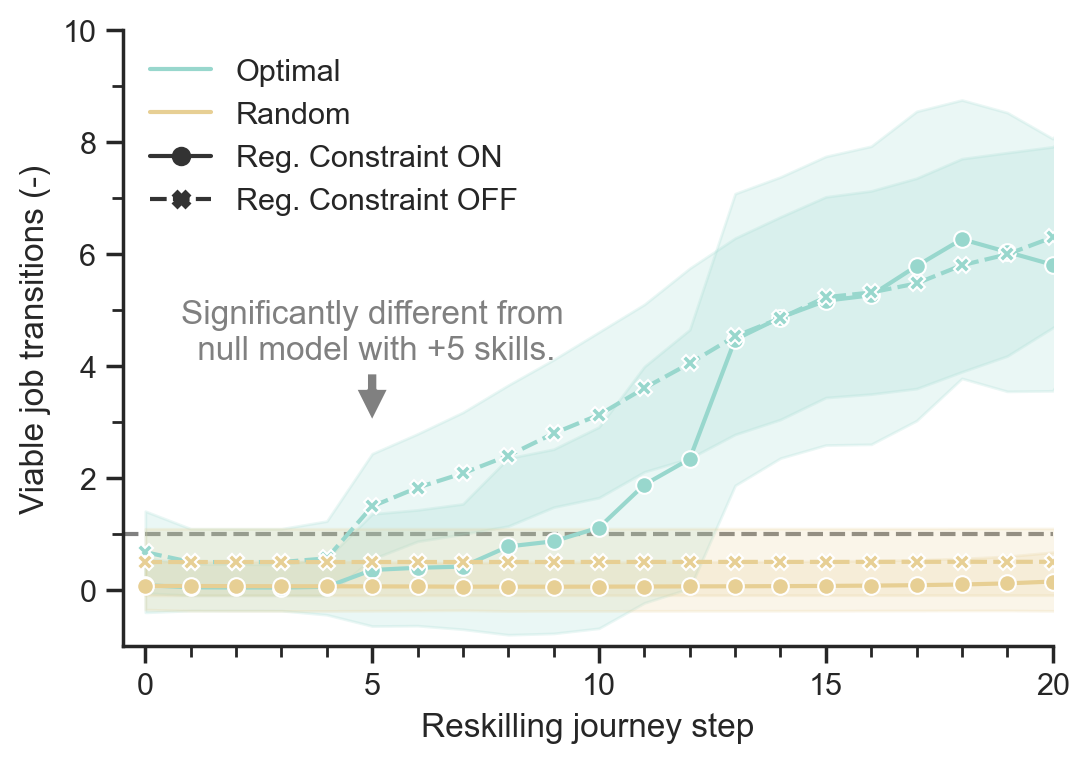

In [100]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "regional_constraint"  # "NACE1D"
size = None

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_transitions,
    x=x,
    y=y,
    hue=hue,
    hue_order=hue_order,
    style=style,
    size=size,
    dashes=True,
    markers=True,
    estimator=estimator,
    errorbar=errorbar,
    palette=palette,
    seed=seed,
    ax=ax,
    legend="brief"
)

# axes limits and ticks
xmax = 20
ymax = 10

ax.set_xlim(-0.5, xmax)
ax.set_ylim(-1, ymax)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

# annotation
x_sign, y_sign = 5, 3
text = "Significantly different from\n null model with +{} skills.".format(x_sign)

ax.annotate(
    text, xy=(x_sign, y_sign),
    xytext=(x_sign, y_sign+1),
    arrowprops=dict(facecolor='grey', shrink=0.01), color="grey",
    horizontalalignment='center', verticalalignment='bottom',
)

# beautify legend
handles, labels = ax.get_legend_handles_labels()
legend_locs = [1, 2, 4, 5]
handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
labels_new = [None, 'Optimal', 'Random', None, 'Reg. Constraint ON', 'Reg. Constraint OFF']
ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False, loc="upper left")

# styling
ax.axhline(1, linestyle="--", color="grey", zorder=0)
ax.set_ylabel("Viable job transitions (-)")
ax.set_xlabel("Reskilling journey step")
#plotting_utils.move_legend_to_right(ax)
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5a: Transition numbers across reskilling journey, Sectors, Appendix

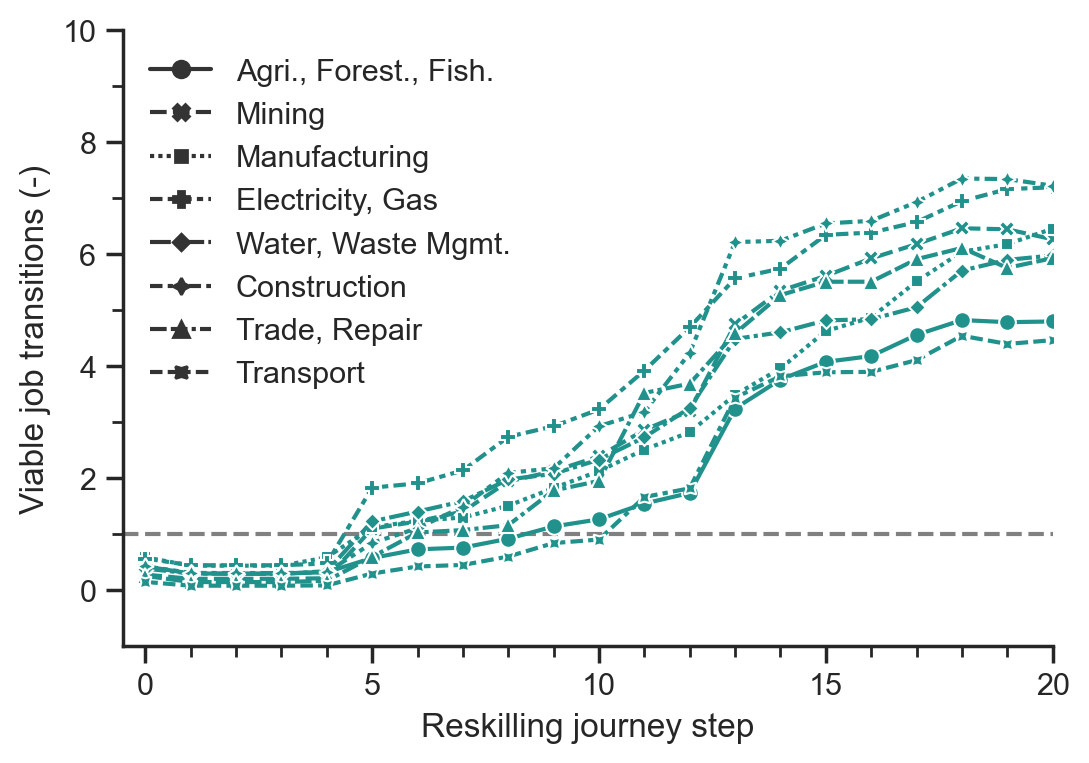

In [126]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label_short"  # "NACE1D"
size = None

# styling
hue_order = ["reskill-optimal"]
order = reskilling_steps
palette = "viridis"
figsize=(6, 4)

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_transitions.loc[data_transitions[hue].isin(hue_order)],
    x=x,
    y=y,
    hue=hue,
    hue_order=hue_order,
    style=style,
    size=size,
    dashes=True,
    markers=True,
    estimator=estimator,
    errorbar=None,
    palette=palette,
    seed=seed,
    ax=ax,
    legend="brief"
)

# axes limits and ticks
xmax = 20
ymax = 10

ax.set_xlim(-0.5, xmax)
ax.set_ylim(-1, ymax)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

# beautify legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="upper left")

# styling
ax.axhline(1, linestyle="--", color="grey", zorder=0)
ax.set_ylabel("Viable job transitions (-)")
ax.set_xlabel("Reskilling journey step")
#plotting_utils.move_legend_to_right(ax)
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}_si.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5a: Transition numbers across reskilling journey, Sectors, Main

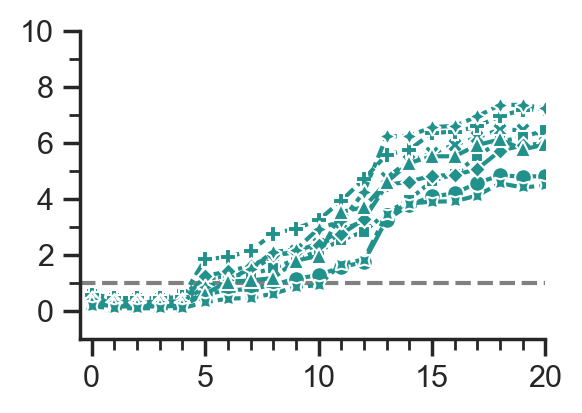

In [127]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label"  # "NACE1D"
size = None

# styling
hue_order = ["reskill-optimal"]
palette = "viridis"
figsize=(3, 2)

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_transitions.loc[data_transitions["reskilling_mode"] == "reskill-optimal"],
    x=x,
    y=y,
    hue=hue,
    hue_order=hue_order,
    style=style,
    size=size,
    dashes=True,
    markers=True,
    estimator=estimator,
    errorbar=None,
    palette=palette,
    seed=seed,
    ax=ax,
    legend=False
)

# axes limits and ticks
xmax = 20
ymax = 10

ax.set_xlim(-0.5, xmax)
ax.set_ylim(-1, ymax)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

# beautify legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="upper left")

# styling
ax.axhline(1, linestyle="--", color="grey", zorder=0)
ax.set_ylabel(None)
ax.set_xlabel(None)
#plotting_utils.move_legend_to_right(ax)
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}_main.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5a: Transition numbers across reskilling journey, Countries, Appendix

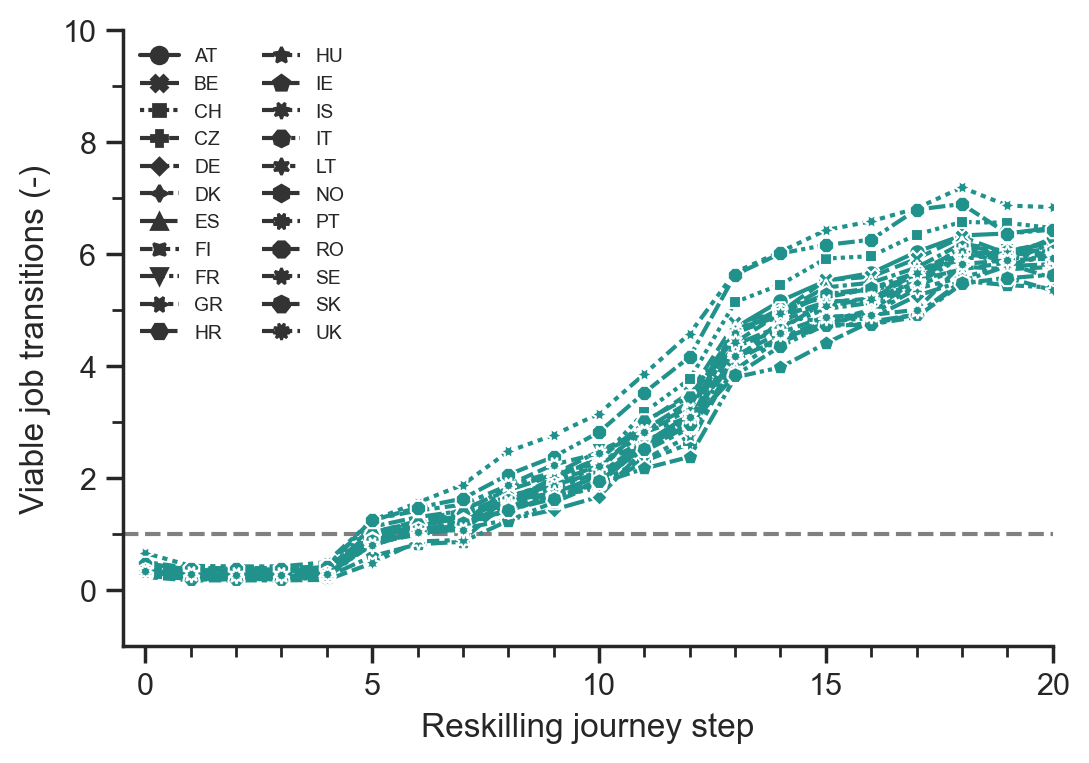

In [138]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "COUNTRYW"  # "NACE1D"
size = None

# styling
hue_order = ["reskill-optimal"]
order = reskilling_steps
palette = "viridis"
figsize=(6, 4)

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_transitions.loc[data_transitions[hue].isin(hue_order)],
    x=x,
    y=y,
    hue=hue,
    hue_order=hue_order,
    style=style,
    size=size,
    dashes=True,
    markers=True,
    estimator=estimator,
    errorbar=None,
    palette=palette,
    seed=seed,
    ax=ax,
    legend="brief"
)

# axes limits and ticks
xmax = 20
ymax = 10

ax.set_xlim(-0.5, xmax)
ax.set_ylim(-1, ymax)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

# beautify legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="upper left", ncol=2, fontsize="xx-small")

# styling
ax.axhline(1, linestyle="--", color="grey", zorder=0)
ax.set_ylabel("Viable job transitions (-)")
ax.set_xlabel("Reskilling journey step")
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}_si.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5a: Transition numbers across reskilling journey, Countries, Main

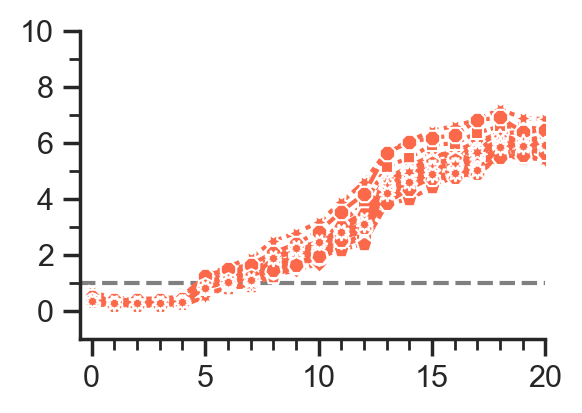

In [140]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "COUNTRYW"  # "NACE1D"
size = None

# styling
hue_order = ["reskill-optimal"]
palette = "Reds"
figsize=(3, 2)

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_transitions,
    x=x,
    y=y,
    hue=hue,
    hue_order=hue_order,
    style=style,
    size=size,
    dashes=True,
    markers=True,
    estimator=estimator,
    errorbar=None,
    palette=palette,
    seed=seed,
    ax=ax,
    legend=False
)

# axes limits and ticks
xmax = 20
ymax = 10

ax.set_xlim(-0.5, xmax)
ax.set_ylim(-1, ymax)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

# styling
ax.axhline(1, linestyle="--", color="grey", zorder=0)
ax.set_ylabel(None)
ax.set_xlabel(None)
#plotting_utils.move_legend_to_right(ax)
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}_main.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5b: Earnings changes across reskilling journey, Boxplot 1

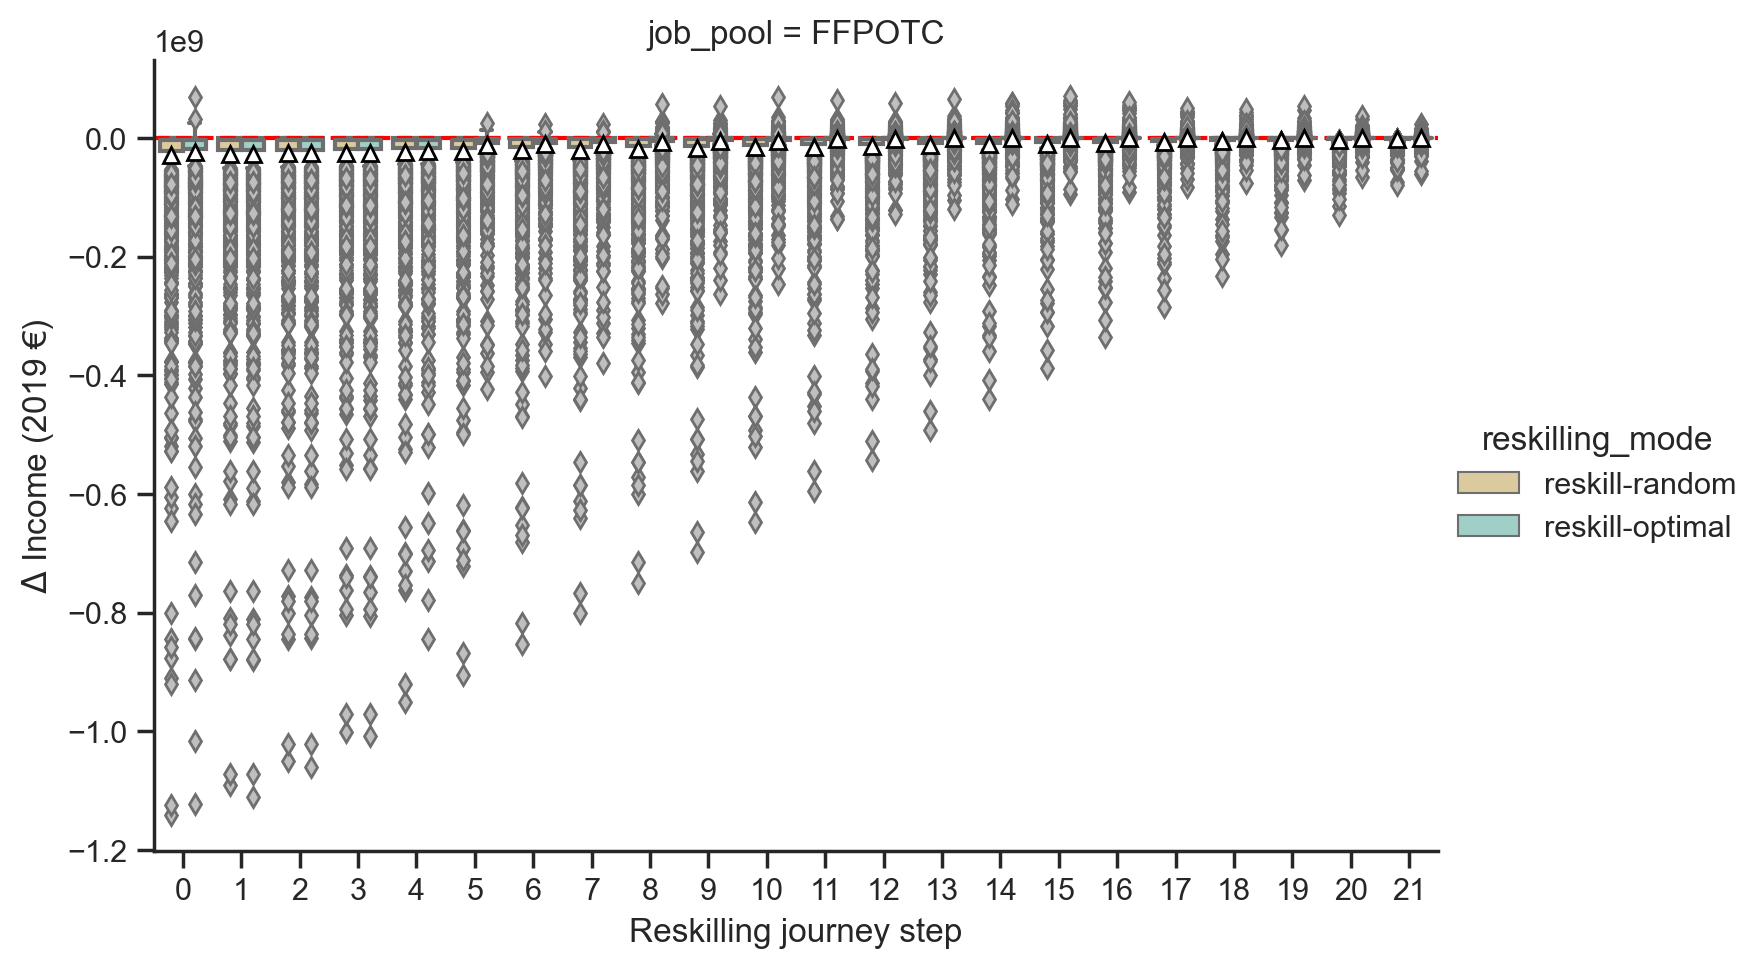

In [91]:
x = "reskilling_step"
y = "earnings_delta"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = [
    # "baseline",

    # "reskill-coreWeight",
    # "reskill-digital",
    "reskill-optimal",
    "reskill-random",
]
order = ["no-regC", "regC"]
sharey = True
kind = "box"

# boxplots
g = sns.catplot(
    data=data_earnings,
    col=col,
    x=x,
    y=y,
    hue=hue,
    # order=order,
    # col_order=col_order,
    # hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1.5,
    palette="BrBG",
)

for ax in g.axes.flatten():
    ax.axhline(0, linestyle="--", color="red")
    ax.set_xlabel("Reskilling journey step")
    ax.set_ylabel("$\Delta$ Income (2019 €)")


##### Fig 5b: Earnings changes across reskilling journey, Boxplots 2

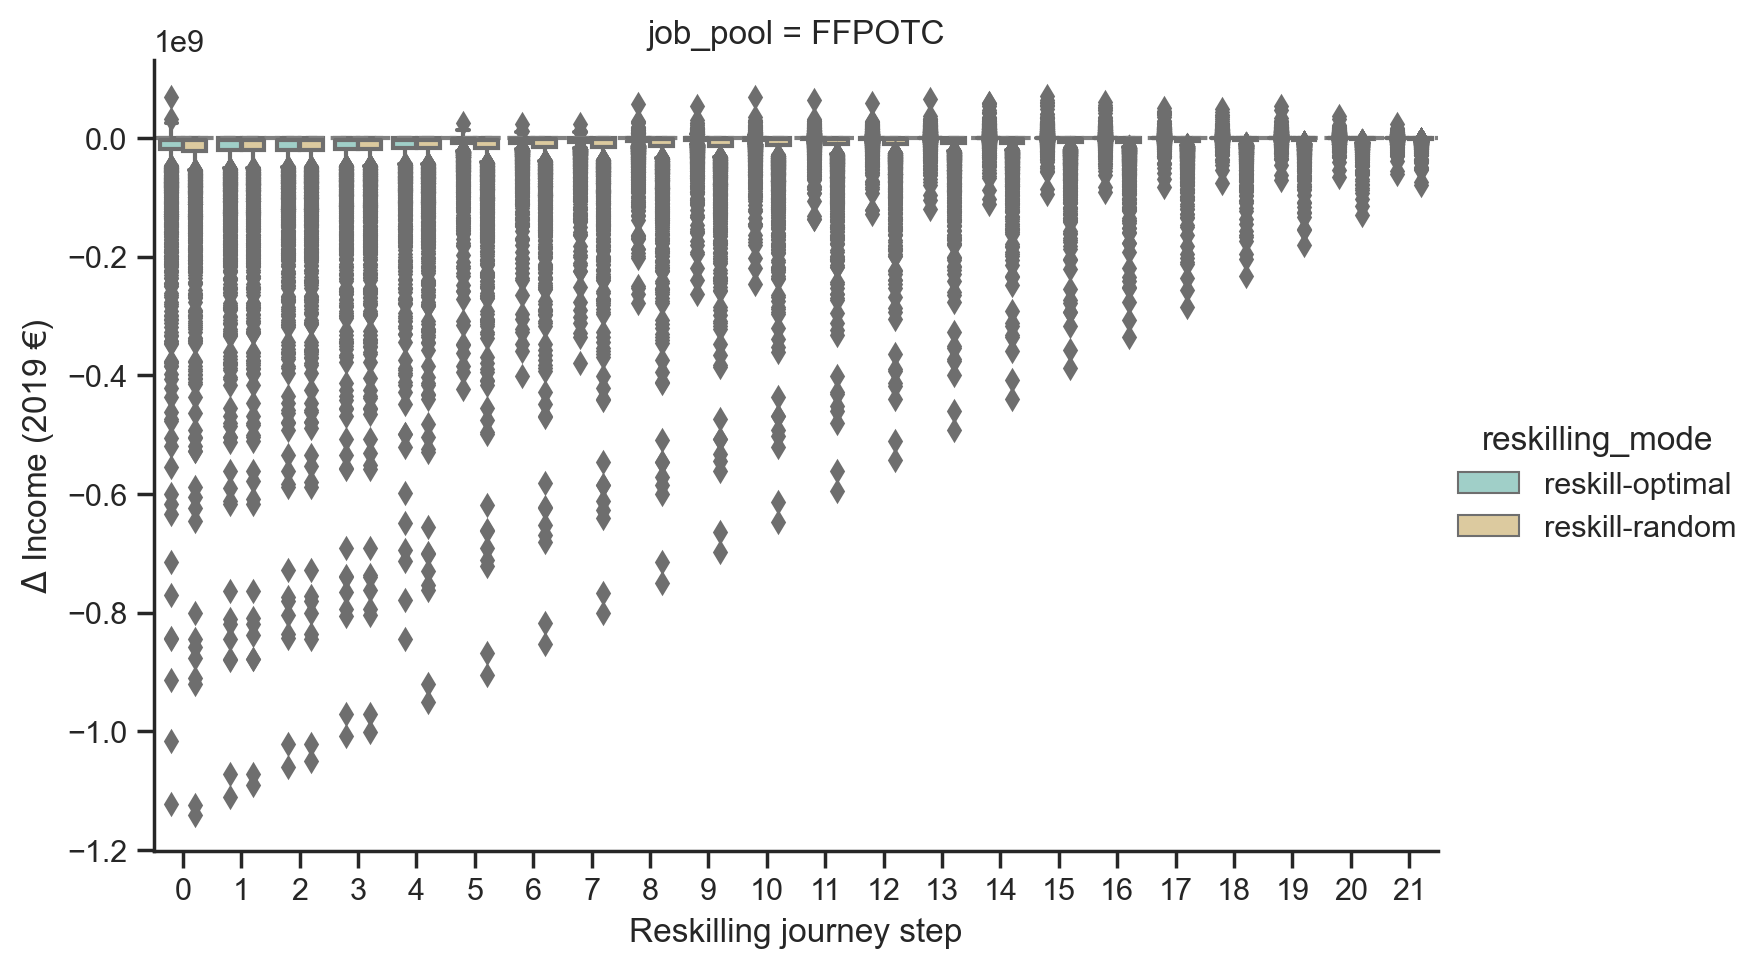

In [92]:
x = "reskilling_step"
y = "earnings_delta"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = [
    "reskill-optimal",
    "reskill-random",
]
palette = "BrBG_r"

# barplot
g = sns.catplot(
    data=data_earnings,
    col=col,
    x=x,
    y=y,
    hue=hue,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    estimator=np.sum,
    height=5,
    aspect=1.5,
    palette=palette,
)

for ax in g.axes.flatten():
    ax.axhline(0, linestyle="--", color="grey")
    ax.set_xlabel("Reskilling journey step")
    ax.set_ylabel("$\Delta$ Income (2019 €)")


##### Fig 5b: Earnings changes across reskilling journey, Main

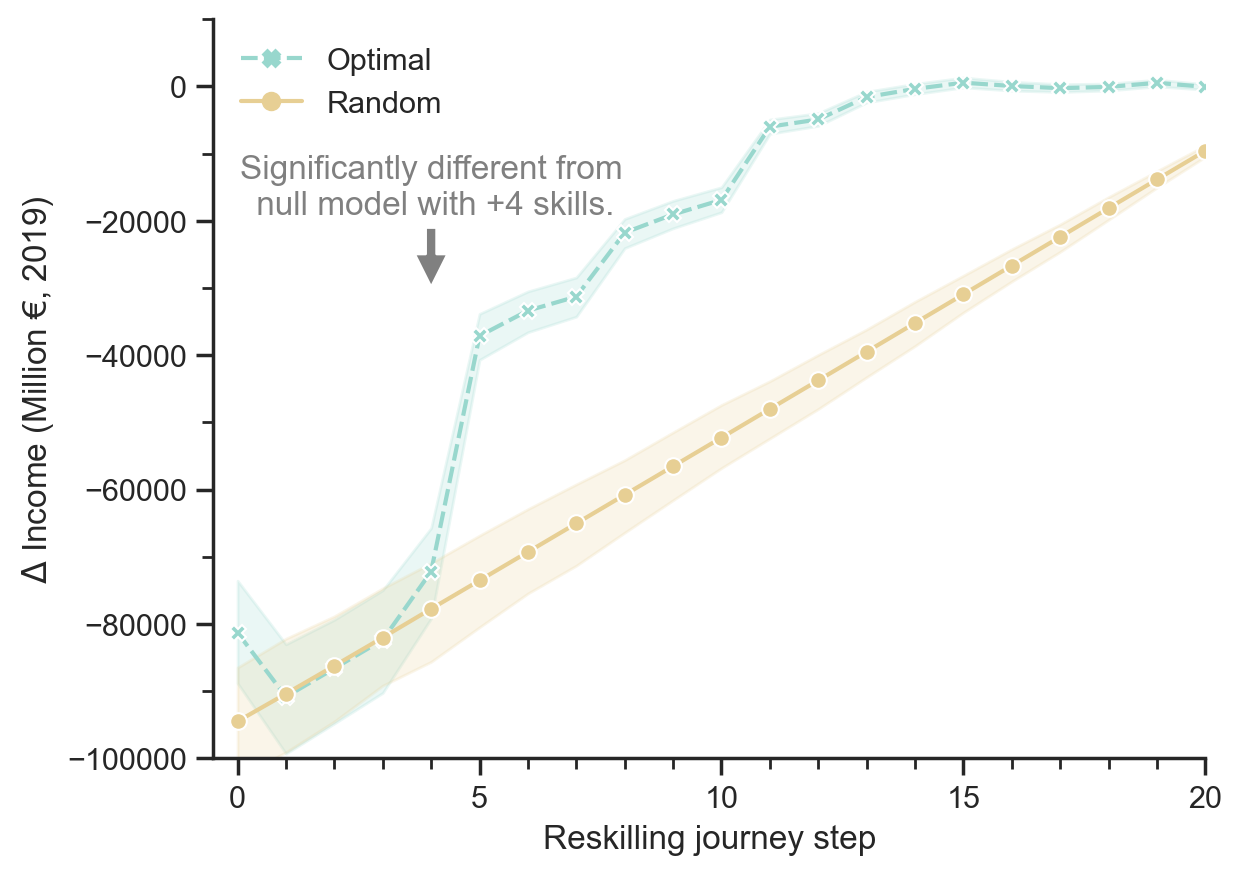

In [156]:
x = "reskilling_step"
y = "earnings_delta_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = hue
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = [
    # "baseline",
    "reskill-optimal",
    "reskill-random",
    # "reskill-coreWeight",
    # "reskill-digital",
]
kind = "bar"
palette = "BrBG_r"

# barplot
ax = sns.lineplot(
    data=data_earnings,
    x=x,
    y=y,
    hue=hue,
    style=style,
    hue_order=hue_order,
    estimator=np.sum,
    markers=True,
    palette=palette,
)

# annotation
x_sign, y_sign = 4, -30000
text = "Significantly different from\n null model with +{} skills.".format(x_sign)
ax.annotate(
    text, xy=(x_sign, y_sign),
    xytext=(x_sign, y_sign+10000),
    arrowprops=dict(facecolor='grey', shrink=0.01), color="grey",
    horizontalalignment='center', verticalalignment='bottom',
)

# beautify legend
handles, legends = ax.get_legend_handles_labels()
legend_locs = [0, 1]
handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
labels_new = ["Optimal", "Random"]
ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False)

# axes limits and ticks
xmax = 20
ymin = -100000

ax.set_xlim(-0.5, xmax)
ax.set_ylim(ymin, 10000)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
# ax.set_yticks(np.arange(ymin, 0, 25000), minor=False)
ax.set_yticks(np.arange(ymin, 10001, 10000), minor=True)

# styling
#ax.axhline(0, linestyle="--", color="grey")
ax.set_xlabel("Reskilling journey step")
ax.set_ylabel("$\Delta$ Income (Million €, 2019)")
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5b: Earnings changes across reskilling journey, Sectors, Appendix

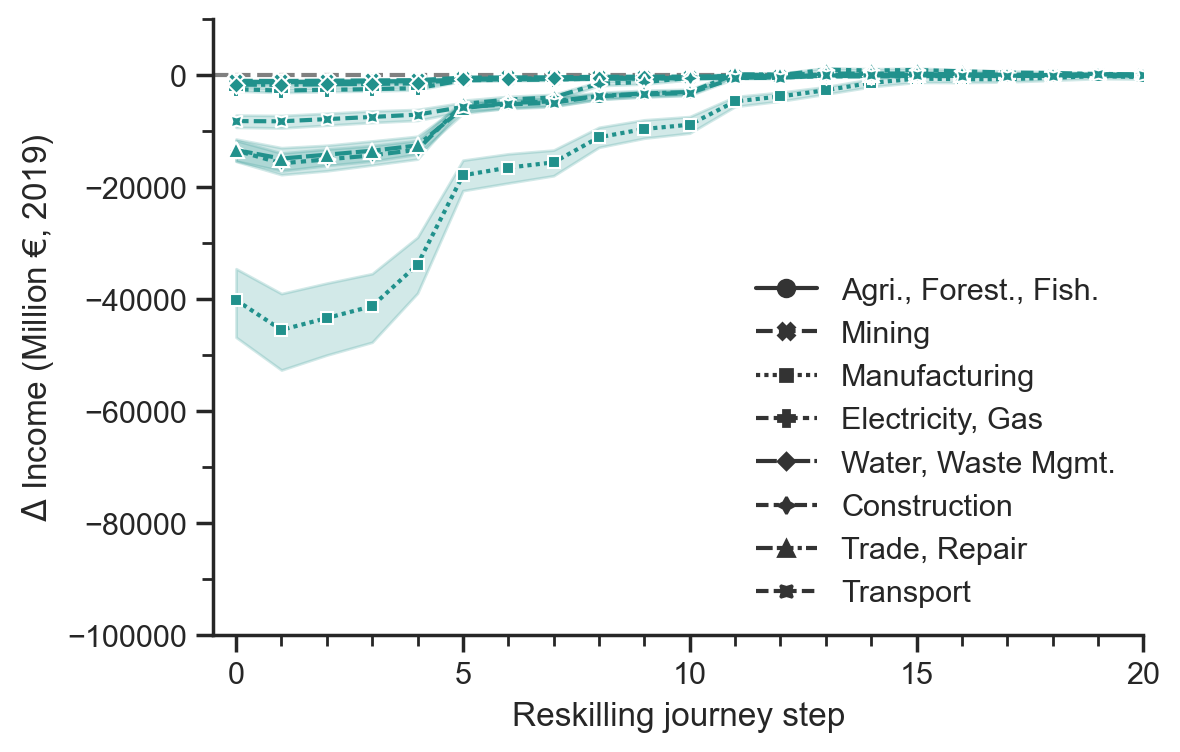

In [161]:
x = "reskilling_step"
y = "earnings_delta_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label_short"
hue_order = ["reskill-optimal"]
palette = "viridis"
figsize=(6, 4)

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_earnings.loc[data_earnings[hue].isin(hue_order)],
    x=x,
    y=y,
    hue=hue,
    style=style,
    hue_order=hue_order,
    estimator=np.sum,
    markers=True,
    palette=palette,
    ax=ax
)

# axes limits and ticks
xmax = 20
ymin = -100000

ax.set_xlim(-0.5, xmax)
ax.set_ylim(ymin, 10000)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
# ax.set_yticks(np.arange(ymin, 0, 25000), minor=False)
ax.set_yticks(np.arange(ymin, 10001, 10000), minor=True)

# beautify legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="lower right")

# styling
ax.axhline(1, linestyle="--", color="grey", zorder=0)
ax.set_ylabel("$\Delta$ Income (Million €, 2019)")
ax.set_xlabel("Reskilling journey step")
#plotting_utils.move_legend_to_right(ax)
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}_si.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5b: Earnings changes across reskilling journey, Sectors, Main

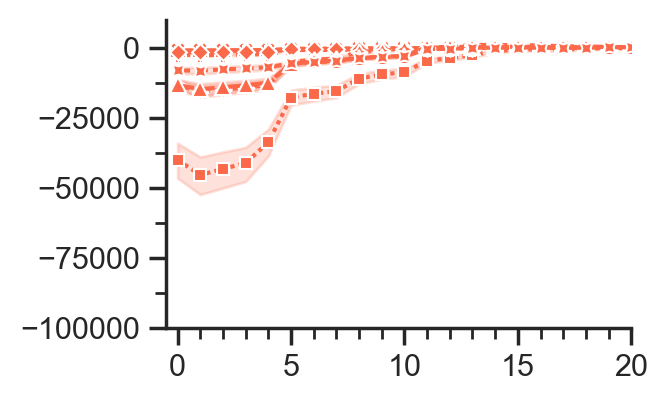

In [163]:
x = "reskilling_step"
y = "earnings_delta_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label"
hue_order = ["reskill-optimal"]
palette = "Reds"
figsize=(3, 2)

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_earnings,
    x=x,
    y=y,
    hue=hue,
    style=style,
    hue_order=hue_order,
    estimator=np.sum,
    markers=True,
    palette=palette,
    ax=ax,
    legend=False
)

# axes limits and ticks
xmax = 20
ymin = -100000

ax.set_xlim(-0.5, xmax)
ax.set_ylim(ymin, 10000)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
# ax.set_yticks(np.arange(ymin, 0, 25000), minor=False)
ax.set_yticks(np.arange(ymin, 10001, 12500), minor=True)

# styling
#ax.axhline(0, linestyle="--", color="grey")
ax.set_xlabel(None)
ax.set_ylabel(None)
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}_main.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5b: Earnings changes across reskilling journey, Countries, Appendix

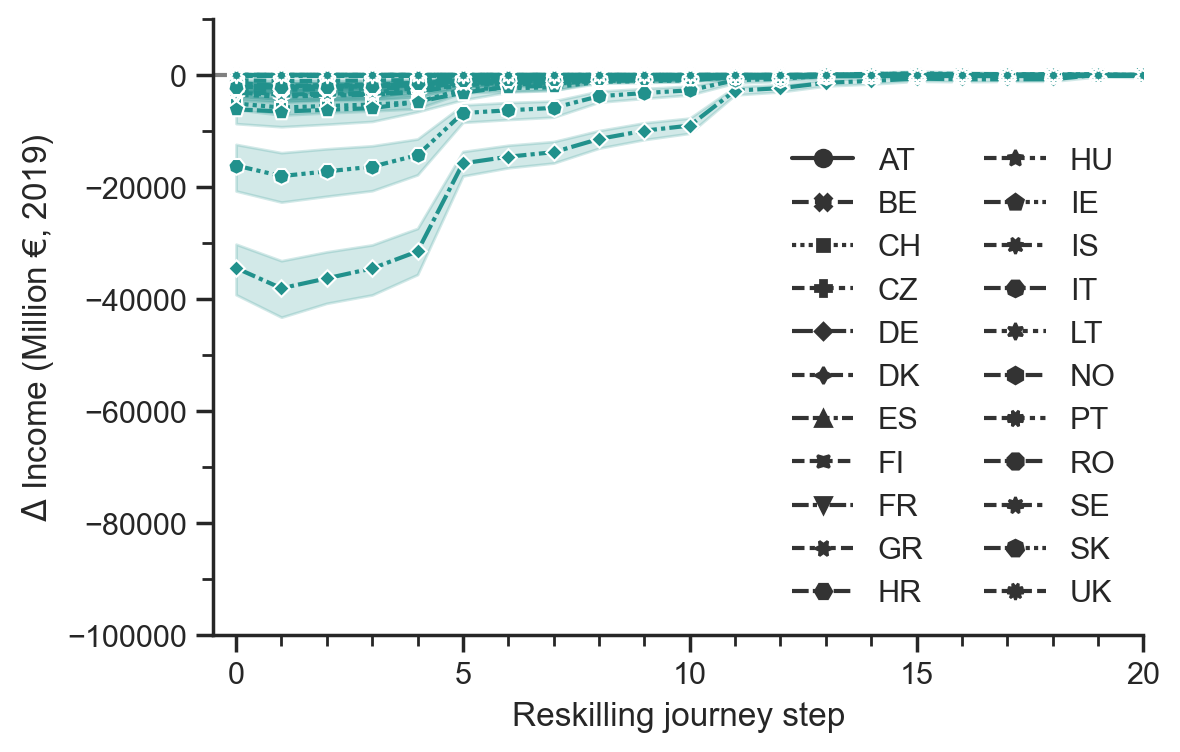

In [166]:
x = "reskilling_step"
y = "earnings_delta_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "COUNTRYW"
hue_order = ["reskill-optimal"]
palette = "viridis"
figsize=(6, 4)

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_earnings,
    x=x,
    y=y,
    hue=hue,
    style=style,
    hue_order=hue_order,
    estimator=np.sum,
    markers=True,
    palette=palette,
    ax=ax
)

# beautify legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="lower right", ncol=2)

# axes limits and ticks
xmax = 20
ymin = -100000

ax.set_xlim(-0.5, xmax)
ax.set_ylim(ymin, 10000)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
# ax.set_yticks(np.arange(ymin, 0, 25000), minor=False)
ax.set_yticks(np.arange(ymin, 10001, 10000), minor=True)

# styling
ax.axhline(1, linestyle="--", color="grey", zorder=0)
ax.set_ylabel("$\Delta$ Income (Million €, 2019)")
ax.set_xlabel("Reskilling journey step")
#plotting_utils.move_legend_to_right(ax)
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}_si.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5b: Earnings changes across reskilling journey, Countries, Main

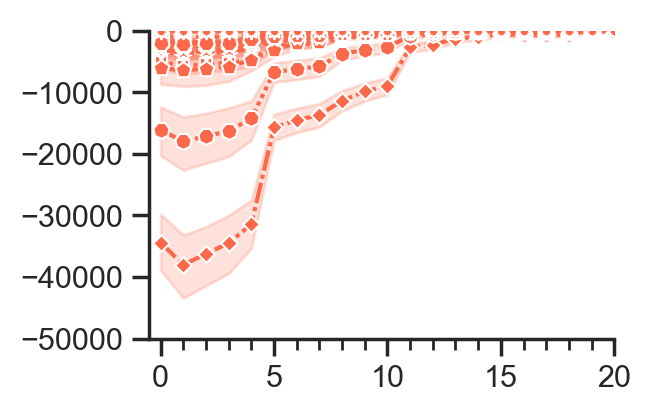

In [172]:
x = "reskilling_step"
y = "earnings_delta_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "COUNTRYW"
hue_order = ["reskill-optimal"]
palette = "Reds"
figsize=(3, 2)

# lineplot
fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(
    data=data_earnings,
    x=x,
    y=y,
    hue=hue,
    style=style,
    hue_order=hue_order,
    estimator=np.sum,
    markers=True,
    palette=palette,
    ax=ax,
    legend=False
)

# axes limits and ticks
xmax = 20
ymin = -50000

ax.set_xlim(-0.5, xmax)
ax.set_ylim(ymin, 0)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
# ax.set_yticks(np.arange(ymin, 0, 25000), minor=False)
# ax.set_yticks(np.arange(ymin, 10001, 10000), minor=True)

# styling
#ax.axhline(0, linestyle="--", color="grey")
ax.set_xlabel(None)
ax.set_ylabel(None)
sns.despine()

# save
plt.savefig(
    os.path.join(
        results_dir,
        "reskilling_journey_{}_{}_by_{}_and_{}_main.png".format(job_pool, y, hue, style),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [96]:
assert 1 == 2

AssertionError: 

#### Transition numbers

##### Regional

Boxplot

In [ ]:
x = "regional_constraint"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = [
    "baseline",
    "reskill-random",
    "reskill-coreWeight",
    "reskill-digital",
    "reskill-optimal",
]
order = ["no-regC", "regC"]
sharey = True
kind = "box"

# boxplots
g = sns.catplot(
    data=df_tidy,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # country-level stripplot
    sns.stripplot(
        x=x,
        y=y,
        data=df_final_by_country.loc[df_final_by_country["job_pool"] == col_order[i]],
        order=order,
        hue_order=hue_order,
        hue=hue,
        dodge=True,
        marker="o",
        size=4,
        edgecolor="black",
        palette=palette,
        alpha=0.5,
        ax=ax,
    )
    ax.legend([], [], frameon=False)

    # # country-level scatterplot
    # sns.scatterplot(
    #     x=hue,
    #     y=y,
    #     data_transitions=df_final_by_country.loc[df_final_by_country["job_pool"] == col_order[i]].dropna(subset=["COUNTRYW"]),
    #     style="COUNTRYW",
    #     hue="COUNTRYW",
    #     marker='o',
    #     size=4,
    #     edgecolor="black",
    #     palette="Paired",
    #     alpha=0.5,
    #     ax=ax,
    # )

    # styling
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(
        ax,
        pairs,
        data=df_tidy,
        x=x,
        y=y,
        order=order,
        hue=hue,
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "test"
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
df_final_by_country.query(
    "(job_pool=='CPO') & (reskilling_mode=='baseline') & (regional_constraint=='no-regC')"
)

In [ ]:
x = "regional_constraint"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = True
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    ci="sd",
    height=5,
    aspect=1,
    palette="BrBG",
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:

    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

Hue = regional constraint

In [ ]:
x = "reskilling_mode"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "regional_constraint"
col = "job_pool"
# order = ["no-regC", "regC"]
sharey = True

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    hue=hue,
    # order=order,
    kind="box",
    sharey=sharey,
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG",
)

axes = g.axes.flatten()
for ax in axes:
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(ax, pairs_regional_hue, data=df_regions, x=x, y=y, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

##### Sectors

In [ ]:
sectors = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]

pairs_sectors = []
for sector in sectors:
    # with regional constraints
    pair = ((sector, "baseline"), (sector, "reskill-optimal"))
    pairs_sectors.append(pair)

In [ ]:
reskilling_modes = ["baseline", "reskill-optimal"]
df = df_sectors.loc[
    df_sectors["paper_selection"] & df_sectors["reskilling_mode"].isin(reskilling_modes)
]

y = "NACE1D_label_short"
x = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"

order = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]
col_order = ["FFPO", "FFPOTC", "CPO"]
hue_order = [
    "baseline",
    "reskill-optimal",
]

sharey = True
kind = "box"

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # styling
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel("Job transition options (-)")

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs_sectors, data=df, x=x, y=y, order=order, hue=hue, orient="h"
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_sector_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
axes

#### Income changes

John Tukey, who was a driving force in the development of exploratory data analysis, defined outliers as points more than 1.5 x IQR. Recall that IQR is the inter-quartile range, which captures 50% of the data points in a data set.

[https://neuraldatascience.io/5-eda/data_cleaning.html]()


##### Regions

Hue = reskilling mode

In [ ]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.sum,
    height=5,
    aspect=1,
    ci=None,
    palette="BrBG"
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=True,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_sum.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    height=5,
    aspect=1,
    ci="sd",
    palette="BrBG"
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_mean.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "box"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    height=5,
    aspect=1,
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG",
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Sectors

In [ ]:
reskilling_modes = ["baseline", "reskill-optimal"]
df = df_sectors.loc[
    df_sectors["paper_selection"] & df_sectors["reskilling_mode"].isin(reskilling_modes)
]

y = "NACE1D_label_short"
x = "earnings_delta_closest_switch_sum_mio"  # n_viable_transitions / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"

order = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]
col_order = ["FFPO", "FFPOTC", "CPO"]
hue_order = [
    "baseline",
    "reskill-optimal",
]

sharey = True
sharex = False
kind = "bar"

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    estimator=np.sum,
    ci="sd",
    # flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # styling
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs_sectors, data=df, x=x, y=y, order=order, hue=hue, orient="h"
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_income_by_sector_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

#### Results by country

In [ ]:
y = "COUNTRYW"
x = "n_viable_transitions"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = True
kind = "box"
palette = "BrBG_r"

# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=False)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

# annotate vline
axes = g.axes.flatten()
for ax in axes:
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Job transition options (-)")  # "Annual earnings changes (M€, 2019)"

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
y = "COUNTRYW"
x = "n_viable_transitions"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = True
kind = "bar"
palette = "BrBG_r"

# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.mean,
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=False)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    ci="sd",
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=7,
    aspect=1,
    palette=palette,
)

aggdict = {
    "n_viable_transitions": [np.mean, np.std],
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}
df_annot = df.groupby(["job_pool", "COUNTRYW", "reskilling_mode"]).agg(aggdict)
df_annot.columns = ["_".join(col) for col in df_annot.columns]
df_annot = df_annot.reindex(order, level=1).reset_index()

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Job transition options (-)")  # "Annual earnings changes (M€, 2019)"

    # annotate numbers (one container per hue level)
    for container in ax.containers:
        df_hue = df_annot.loc[
            (df_annot[hue] == container.get_label())
            & (df_annot["job_pool"] == col_order[i])
        ]
        labels = (
            df_hue.loc[:, "n_viable_transitions_mean"].round(1).astype(str)
            + r" $\pm$ "
            + df_hue.loc[:, "n_viable_transitions_std"].round(1).astype(str)
        )
        ax.bar_label(container, labels=labels, fontsize=8, label_type="center")

        # annotate mean
        x = df_hue["n_viable_transitions_mean"].mean()
        c = container[-1].get_facecolor()
        ax.axvline(x, linestyle="--", color=c, label=r"$\mu$")  # , zorder=0)

        ax.text(
            x,
            0,
            "$\mu = {:.1f}$".format(x),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8,
        )

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
ax.containers[0][-1].get_facecolor()

In [ ]:
df_hue

In [ ]:
df_annot

In [ ]:
y = "COUNTRYW"
x = "earnings_delta_closest_switch_sum_mio"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = False
kind = "box"
palette = "BrBG_r"

aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
    & (~df_regions["COUNTRYW"].isin(earnings_data_missing))
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=True)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.grid(linestyle=":", axis="x")
    ax.axvline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
y = "COUNTRYW"
x = "earnings_delta_closest_switch_sum_mio"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = False
kind = "bar"
palette = "BrBG_r"

aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

# calc order
df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
    & (~df_regions["COUNTRYW"].isin(earnings_data_missing))
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=True)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    estimator=np.sum,
    ci=False,
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

df_annot = df.groupby(["job_pool", "COUNTRYW", "reskilling_mode"]).agg(aggdict)
df_annot = df_annot.reindex(order, level=0).reset_index()

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.axvline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")
    ax.grid(linestyle=":", axis="x")

    # annotate numbers (one container per hue level)
    for container in ax.containers:
        df_hue = df_annot.loc[
            (df_annot[hue] == container.get_label())
            & (df_annot["job_pool"] == col_order[i])
        ]
        ax.bar_label(
            container, labels=df_hue[x], fmt="%.0f", fontsize=8, label_type="edge"
        )
        # annotate mean
        pos = np.nanmean(df_hue["earnings_delta_closest_switch_sum_mio"])
        c = container[-1].get_facecolor()
        ax.axvline(pos, linestyle="--", color=c, label=r"$\mu$")  # , zorder=0)

        ax.text(
            pos,
            0,
            r"$\mu = {:.1f}$".format(pos),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8,
        )

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
df_hue